# Safehouse strain and capacity pressure (Hiraya Haven)

**Pipeline:** Forecast monthly incident load and stress indicators per safehouse, and explain correlates of high-incident months.

**Data:** `safehouse_monthly_metrics`, `incident_reports`, `residents` (via `hiraya.db`), aligned with the INTEX dataset domains in `IntexContext.txt`.

**Outputs:** (1) predictive model for next month’s incident count (supervised forecasting with lag features); (2) explanatory model for same-month correlates of elevated incidents; (3) deployment notes for the Hiraya Haven web app.

## 1. Problem framing

**Organization:** Hiraya Haven operates safe homes and rehabilitation services for girls who are survivors of abuse and trafficking. Staff are stretched across multiple safehouses and need to know where operational pressure is building before crises accumulate (`IntexContext.txt`).

**Business question:** *Which safehouses show rising safety incidents or weakening average progress (education / health), and can we anticipate next month’s incident load so leadership can reallocate staff, supervision, or partner support?*

**Who cares:** Program directors and house supervisors (risk and quality of care); leadership (resource allocation); ultimately residents (safety and outcomes).

### Predictive vs explanatory (textbook framing)

- **Predictive goal:** Estimate **next month’s incident count** per safehouse from past monthly indicators (lags, trends, occupancy). Success is measured by **out-of-sample error** on held-out time periods, not by interpreting individual coefficients as causal.
- **Explanatory goal:** Quantify **associations** between same-month operational metrics (education progress, health scores, visit/process activity, occupancy) and **high-incident months**, using an interpretable model. Here we prioritize **clarity of coefficients / directions** and honest limits on causal claims.

**Ethics / privacy:** This notebook uses **aggregate monthly safehouse data** only—no resident names or free-text counseling notes—to reduce re-identification risk while still supporting operations.

## 2. Data acquisition, preparation, and exploration

**Sources (SQLite `hiraya.db`):**

- `safehouse_monthly_metrics` — one row per safehouse per month: `incident_count`, `avg_education_progress`, `avg_health_score`, `active_residents`, visit/process counts, etc.
- `incident_reports` — row-level incidents (used to validate aggregates and engineer **severity-weighted** monthly counts).
- `residents` — current caseload by safehouse (cross-sectional counts; complements `active_residents` in the monthly table).

**Join logic:** Monthly metrics are the **spine**. We aggregate `incident_reports` by `(safehouse_id, month)` to compare with `incident_count`, then build a **panel** sorted by safehouse and month for lag features. **Target** for forecasting is **next month’s** `incident_count` within each safehouse (`shift(-1)` within group).

**Reproducibility:** Paths are relative to this notebook location (`ml-pipelines/` → `../Data/hiraya.db`). Regenerate the DB with `db/sqlite/load_csv_to_sqlite.py` if needed.

In [1]:
# ============================================================================
# Safehouse strain — Load monthly metrics, incidents, residents, safehouses
# ============================================================================
# Notebook code cell overview — see inline comments below.
#
# Validates DB paths; suppresses noisy sklearn warnings for cleaner notebook output.
#
from __future__ import annotations

import sqlite3
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid", context="notebook")

ROOT = Path("..").resolve()
DB_PATH = ROOT / "Data" / "hiraya.db"

if not DB_PATH.exists():
    raise FileNotFoundError(
        f"Database not found at {DB_PATH}. Run: python db/sqlite/load_csv_to_sqlite.py "
        "--csv-dir Data --db-path Data/hiraya.db --overwrite"
    )


def read_sql(conn: sqlite3.Connection, sql: str) -> pd.DataFrame:
    return pd.read_sql_query(sql, conn)


with sqlite3.connect(DB_PATH) as conn:
    monthly = read_sql(conn, 'SELECT * FROM "safehouse_monthly_metrics"')
    incidents = read_sql(conn, 'SELECT * FROM "incident_reports"')
    residents = read_sql(conn, 'SELECT * FROM "residents"')
    safehouses = read_sql(conn, 'SELECT safehouse_id, safehouse_code, name, region FROM "safehouses"')

monthly["month_start"] = pd.to_datetime(monthly["month_start"])
incidents["incident_date"] = pd.to_datetime(incidents["incident_date"])
incidents["month"] = incidents["incident_date"].dt.to_period("M").dt.to_timestamp()

print("monthly rows:", len(monthly), "| incidents:", len(incidents), "| residents:", len(residents))

monthly rows: 450 | incidents: 100 | residents: 60


Aggregate check: incident_count vs row count from incident_reports (should often match):
count    450.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: match_diff, dtype: float64


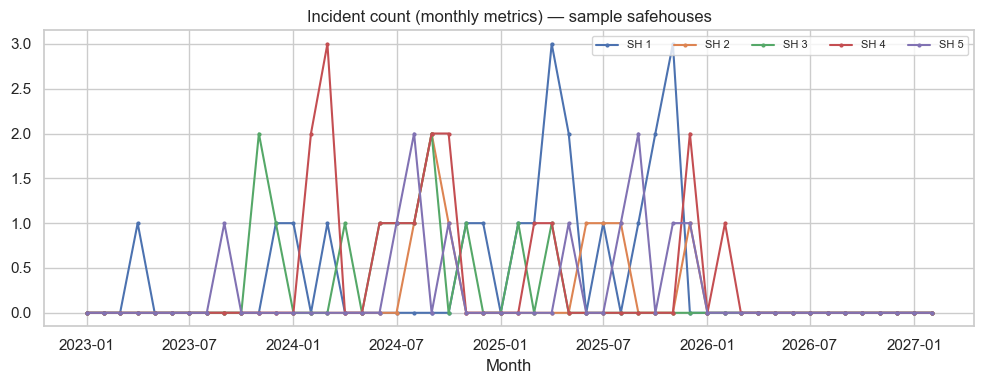

In [2]:
# ============================================================================
# Data quality — Compare incident_counts in monthly metrics vs raw incident_reports
# ============================================================================
# Notebook code cell overview — see inline comments below.
#
# Plots sample safehouses for visual sanity; merges resident counts per safehouse.
#
SEVERITY_MAP = {"Low": 1, "Medium": 2, "High": 3}
incidents["severity_weight"] = incidents["severity"].map(SEVERITY_MAP).fillna(1)

agg_from_reports = (
    incidents.groupby(["safehouse_id", "month"], as_index=False)
    .agg(
        incident_rows=("incident_id", "count"),
        severity_sum=("severity_weight", "sum"),
    )
    .rename(columns={"month": "month_start"})
)

monthly_enriched = monthly.merge(safehouses, on="safehouse_id", how="left")
compare = monthly_enriched.merge(
    agg_from_reports,
    on=["safehouse_id", "month_start"],
    how="left",
    suffixes=("", "_from_reports"),
)
compare["incident_rows"] = compare["incident_rows"].fillna(0).astype(int)
compare["match_diff"] = compare["incident_count"] - compare["incident_rows"]
print("Aggregate check: incident_count vs row count from incident_reports (should often match):")
print(compare["match_diff"].describe())

resident_counts = residents.groupby("safehouse_id", as_index=False).size().rename(columns={"size": "resident_records_count"})
monthly_enriched = monthly_enriched.merge(resident_counts, on="safehouse_id", how="left")

fig, ax = plt.subplots(figsize=(10, 4))
for sid in sorted(monthly_enriched["safehouse_id"].unique())[:5]:
    sub = monthly_enriched.loc[monthly_enriched["safehouse_id"] == sid]
    ax.plot(sub["month_start"], sub["incident_count"], marker="o", ms=2, label=f"SH {sid}")
ax.set_title("Incident count (monthly metrics) — sample safehouses")
ax.set_xlabel("Month")
ax.legend(ncol=5, fontsize=8)
plt.tight_layout()
plt.show()


### Feature engineering (panel + lags)

- **Sort** by `safehouse_id`, `month_start`.
- **Lags** within safehouse: prior month incident count, education progress, health score.
- **Trend:** month-over-month change in `avg_education_progress`.
- **Target (predictive):** `incident_count_next` = next month’s `incident_count` (group `shift(-1)`).
- **Stress index (optional composite):** z-scores within each month across safehouses: higher incidents + lower education progress + lower health → higher strain (for dashboards; not required for modeling).

**Prediction time & leakage:** The target is **month \(t+1\)** incident count. Features include **month \(t\)** totals (`incident_count`, visitation/process activity, `active_residents`, `resident_records_count`) plus **lags** from \(t-1\)/\(t-2\). That matches a forecast made **at end of month \(t\)**. If you need a forecast **before** month \(t\) ends, omit same-month features and use only lags.

In [3]:
# ============================================================================
# Feature engineering — Lags, deltas, within-month z-scores, stress_index
# ============================================================================
# Notebook code cell overview — see inline comments below.
#
# Per-safehouse time series: shift(1)/shift(2) inject past strain; shift(-1) defines next-month target.
# stress_index_z combines standardized incident pressure minus education/health z-scores (exploratory).
# model_df drops rows without lag1 or undefined next month — aligns supervised rows.
#
df = monthly_enriched.sort_values(["safehouse_id", "month_start"]).copy()

g = df.groupby("safehouse_id", group_keys=False)
df["incident_lag1"] = g["incident_count"].shift(1)
df["incident_lag2"] = g["incident_count"].shift(2)
df["edu_lag1"] = g["avg_education_progress"].shift(1)
df["health_lag1"] = g["avg_health_score"].shift(1)
df["edu_delta"] = g["avg_education_progress"].diff(1)
df["incident_count_next"] = g["incident_count"].shift(-1)

for col in ["avg_education_progress", "avg_health_score"]:
    z = df.groupby("month_start")[col].transform(
        lambda s: (s - s.mean()) / s.std(ddof=0) if s.std(ddof=0) > 0 else 0
    )
    df[f"{col}_z_within_month"] = z

z_inc = df.groupby("month_start")["incident_count"].transform(
    lambda s: (s - s.mean()) / s.std(ddof=0) if s.std(ddof=0) > 0 else 0
)
df["stress_index_z"] = (
    z_inc
    - df["avg_education_progress_z_within_month"].fillna(0)
    - df["avg_health_score_z_within_month"].fillna(0)
)

# Rows need a prior month for lag-1 incidents and a defined next-month target.
# Education/health lags can be missing in early months; impute in X (below).
model_df = df.dropna(
    subset=[
        "incident_lag1",
        "incident_count_next",
    ]
).copy()

print(model_df.shape)
model_df[["incident_count", "incident_count_next", "stress_index_z"]].describe()


(432, 24)


,incident_count,incident_count_next,stress_index_z
count,432.000000,432.000000,4.320000e+02
mean,0.231481,0.231481,2.467162e-16
std,0.546773,0.546773,1.543579e+00
min,0.000000,0.000000,-3.577301e+00
25%,0.000000,0.000000,-7.071068e-01
50%,0.000000,0.000000,0.000000e+00
75%,0.000000,0.000000,3.427920e-01
max,3.000000,3.000000,5.591308e+00


## 3. Modeling and feature selection

**Predictive:** Regress `incident_count_next` on **same-month** and **lagged** operational features (see code comments). **Ridge** uses `StandardScaler` + `Pipeline` so coefficients are on comparable scales; **RandomForestRegressor** does not require scaling. **Time-based split** by calendar month (not random shuffle) respects temporal order.

**Explanatory:** Classify **high-incident month** (binary: `incident_count >= 1` or top quartile within dataset—configurable) from **same-month** predictors (`avg_education_progress`, `avg_health_score`, `active_residents`, `home_visitation_count`, `process_recording_count`). **Logistic regression** with scaling for interpretability.

**Feature selection rationale:** Prior-month incidents are strong autoregressive signals; education/health capture “progress” pressure; activity counts proxy staffing/caseload intensity. We omit raw identifiers and free text.

In [4]:
# ============================================================================
# Predictive models — Ridge vs RandomForest for next-month incident count
# ============================================================================
# Notebook code cell overview — see inline comments below.
#
# Train on earlier months, test on later — operational forecasting use case for staffing.
# RF feature importances show which operational signals dominate (interpret cautiously).
#
unique_months = sorted(model_df["month_start"].unique())
cut = unique_months[int(0.75 * len(unique_months))]
train_mask = model_df["month_start"] < cut
test_mask = ~train_mask

# Prediction time: end of month t; target is incident_count in month t+1.
# incident_count = same-month incidents (known at month-end); aligns with visitation/process counts.
feature_cols = [
    "incident_count",
    "incident_lag1",
    "incident_lag2",
    "edu_lag1",
    "health_lag1",
    "edu_delta",
    "active_residents",
    "home_visitation_count",
    "process_recording_count",
    "resident_records_count",
]
X_train = model_df.loc[train_mask, feature_cols].fillna(0)
y_train = model_df.loc[train_mask, "incident_count_next"]
X_test = model_df.loc[test_mask, feature_cols].fillna(0)
y_test = model_df.loc[test_mask, "incident_count_next"]

print(f"Time cutoff: train month < {cut.date()} | train n={len(y_train)} test n={len(y_test)}")

ridge_pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=1.0)),
    ]
)
ridge_pipe.fit(X_train, y_train)
pred_ridge = ridge_pipe.predict(X_test)

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nRandomForest feature importances:\n", imp)


Time cutoff: train month < 2026-02-01 | train n=324 test n=108

RandomForest feature importances:
 process_recording_count    0.329331
edu_delta                  0.134827
edu_lag1                   0.134642
health_lag1                0.123826
home_visitation_count      0.087916
incident_count             0.080915
incident_lag1              0.036673
incident_lag2              0.032179
resident_records_count     0.021458
active_residents           0.018232
dtype: float64


In [5]:
# ============================================================================
# Explanatory logistic — high_incident from wellness + workload proxies
# ============================================================================
# Notebook code cell overview — see inline comments below.
#
# Separate from forecasting: classifies whether incidents cross a threshold this month.
# Coefficients on standardized features are directional associations.
#
expl_df = df.dropna(
    subset=["avg_education_progress", "avg_health_score", "incident_count"]
).copy()
expl_df["high_incident"] = (expl_df["incident_count"] >= 1).astype(int)

exp_months = sorted(expl_df["month_start"].unique())
exp_cut = exp_months[int(0.75 * len(exp_months))]
tr_e = expl_df["month_start"] < exp_cut
te_e = ~tr_e

exp_features = [
    "avg_education_progress",
    "avg_health_score",
    "active_residents",
    "home_visitation_count",
    "process_recording_count",
]
X_e_train = expl_df.loc[tr_e, exp_features].fillna(0)
y_e_train = expl_df.loc[tr_e, "high_incident"]
X_e_test = expl_df.loc[te_e, exp_features].fillna(0)
y_e_test = expl_df.loc[te_e, "high_incident"]

log_pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "clf",
            LogisticRegression(max_iter=200, class_weight="balanced", random_state=42),
        ),
    ]
)
log_pipe.fit(X_e_train, y_e_train)
proba = log_pipe.predict_proba(X_e_test)[:, 1]
pred_cls = (proba >= 0.5).astype(int)

coefs = pd.Series(
    log_pipe.named_steps["clf"].coef_.ravel(),
    index=exp_features,
)
print("Logistic coefficients (standardized features):\n", coefs.sort_values())

Logistic coefficients (standardized features):
 active_residents          -0.148066
avg_health_score          -0.113492
avg_education_progress     0.015147
home_visitation_count      0.317140
process_recording_count    0.736845
dtype: float64


## 4. Evaluation and interpretation

**Predictive (regression):** Report MAE, RMSE, and \(R^2\) on the **held-out future months**. Lower error means better staffing alerts; perfect prediction is not expected for rare count data.

**Explanatory (classification):** Report accuracy, F1, and ROC-AUC for high-incident months. **False negatives** (predicting calm when incidents spike) could delay support; **false positives** waste supervisor time—balance matters for Hiraya Haven.

**Interpretation:** Compare Ridge vs forest: if forest wins materially, nonlinearities or interactions matter; if similar, simpler linear forecasts may suffice for deployment.

In [6]:
# ============================================================================
# Report metrics — Regression errors and classification accuracy/AUC
# ============================================================================
# Notebook code cell overview — see inline comments below.
#
# Consolidated printout for notebooks; same functions could log to MLflow in larger projects.
#
def report_reg(name: str, y_true: np.ndarray, y_pred: np.ndarray) -> None:
    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2 = r2_score(y_true, y_pred)
    print(f"{name}: MAE={mae:.3f} RMSE={rmse:.3f} R2={r2:.3f}")


report_reg("Ridge (scaled)", y_test.values, pred_ridge)
report_reg("RandomForest", y_test.values, pred_rf)

_acc = round(accuracy_score(y_e_test, pred_cls), 3)
_f1 = round(f1_score(y_e_test, pred_cls, zero_division=0), 3)
if y_e_test.nunique() < 2:
    _auc = float("nan")
else:
    _auc = round(roc_auc_score(y_e_test, proba), 3)
print(
    "\nLogistic (high_incident): acc=",
    _acc,
    "f1=",
    _f1,
    "roc_auc=",
    _auc,
)


Ridge (scaled): MAE=0.079 RMSE=0.139 R2=-1.095
RandomForest: MAE=0.119 RMSE=0.172 R2=-2.241

Logistic (high_incident): acc= 0.537 f1= 0.578 roc_auc= 0.536


## 5. Causal and relationship analysis

**What we can say from the data:**

- **Autoregression:** Same-month `incident_count` and `incident_lag1` / `incident_lag2` often dominate short-horizon count forecasting; that is expected and should be interpreted as persistence, not necessarily “causal drivers” of next month.
- **Progress and health:** Lower `avg_education_progress` or `avg_health_score` *in the same month* may co-occur with incidents in the explanatory logistic model—but this is **association**, not proof that low scores *cause* incidents. Reverse causation (incidents disrupt programming) and **omitted variables** (staffing, external events) are plausible.
- **Operational intensity:** Higher `process_recording_count` or `home_visitation_count` might reflect either healthy documentation or elevated case complexity—interpret with domain input.

**Causal humility:** Hiraya Haven should use the **forecast** as a triage signal and the **explanatory** model as hypothesis generation for supervision and quality improvement, not as justification for punitive responses toward staff or residents.

**Most impactful features (typical patterns):** Check the printed Random Forest importances and logistic coefficients above; rank features by magnitude and discuss whether the direction aligns with staff experience.

## 6. Deployment notes (Hiraya Haven web app)

**Intended integration:**

1. **Admin dashboard widget:** “Safehouse pressure” — show **forecast next-month incident count** (with confidence band if you later add quantile regression) and **month-to-date** vs trailing average.
2. **API sketch:** `GET /api/analytics/safehouse-strain?safehouseId=&month=` returns lag features, prediction, and flags when forecast exceeds a threshold (configurable per region).
3. **Batch refresh:** Nightly job reads `hiraya.db` or production PostgreSQL, rebuilds panel features, writes scores to a `safehouse_strain_scores` table for the React front end.

**Monitoring:** Track MAE/RMSE over rolling windows; alert if drift spikes after policy changes.

**This repo:** Model training lives in this notebook under `ml-pipelines/`; database loading is documented in `db/sqlite/README.md`. Wire the saved `RandomForest` / `Ridge` object via `joblib.dump` in a follow-on commit when the .NET API is ready.